#  Deepfake Audio Detection


## 0. Install & Imports


In [1]:

import os
import numpy as np
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'Librosa version: {librosa.__version__}')

Device: cuda
PyTorch version: 2.10.0+cu128
Librosa version: 0.11.0


## 1. Configuration


In [2]:
# ── Paths 
DATA_ROOT  = '/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training'
CACHE_DIR  = './feature_cache'
MODEL_PATH = './best_model.pt'

# ── Audio 
# All clips resampled to 16kHz (standard for speech processing)
# and trimmed/padded to exactly 4 seconds - fixed-size feature maps
SR         = 16000
DURATION   = 4.0
N_SAMPLES  = int(SR * DURATION)  

# ── Feature Extraction 
# 40 LFCC + 40 MFCC = 80 feature rows per time frame
# HOP_LENGTH=160 - 10ms frame shift (standard in speech)
# N_FFT=512 - ~32ms window at 16kHz
N_MFCC     = 40
N_LFCC     = 40
HOP_LENGTH = 160
N_FFT      = 512
# Time frames T = floor(N_SAMPLES / HOP_LENGTH) + 1 = 401

# ── Training 
BATCH_SIZE = 64
EPOCHS     = 20
LR         = 1e-3
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.10

print('Config set.')
print(f'  Audio: {SR}Hz, {DURATION}s → {N_SAMPLES} samples per clip')
print(f'  Features: {N_LFCC} LFCC + {N_MFCC} MFCC = {N_LFCC+N_MFCC} rows × 401 time frames')

Config set.
  Audio: 16000Hz, 4.0s → 64000 samples per clip
  Features: 40 LFCC + 40 MFCC = 80 rows × 401 time frames


## 2. Exploratory Data Analysis (EDA)


### 2.1 Dataset Statistics

  Genuine (Real) clips : 26,941
  Deepfake clips       : 26,927
  Total                : 53,868
  Class balance        : 50.0% / 50.0%


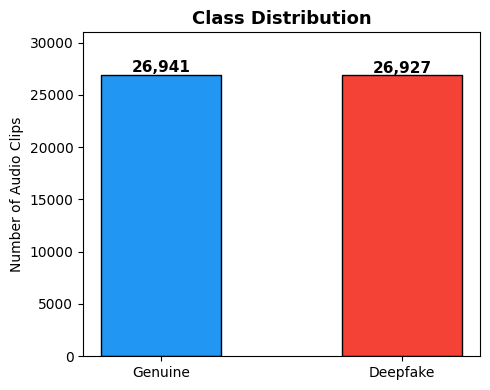

In [3]:
real_files = [f for f in os.listdir(os.path.join(DATA_ROOT, 'real'))
              if f.endswith('.wav') or f.endswith('.flac')]
fake_files = [f for f in os.listdir(os.path.join(DATA_ROOT, 'fake'))
              if f.endswith('.wav') or f.endswith('.flac')]

print('=' * 40)
print(f'  Genuine (Real) clips : {len(real_files):,}')
print(f'  Deepfake clips       : {len(fake_files):,}')
print(f'  Total                : {len(real_files)+len(fake_files):,}')
print(f'  Class balance        : {len(real_files)/(len(real_files)+len(fake_files))*100:.1f}% / {len(fake_files)/(len(real_files)+len(fake_files))*100:.1f}%')
print('=' * 40)

# Bar chart
plt.figure(figsize=(5, 4))
bars = plt.bar(['Genuine', 'Deepfake'], [len(real_files), len(fake_files)],
               color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
for bar, val in zip(bars, [len(real_files), len(fake_files)]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')
plt.title('Class Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Audio Clips')
plt.ylim(0, max(len(real_files), len(fake_files)) * 1.15)
plt.tight_layout()
plt.savefig('/kaggle/working/eda_class_distribution.png', dpi=150)
plt.show()


### 2.2 Audio Duration Distribution


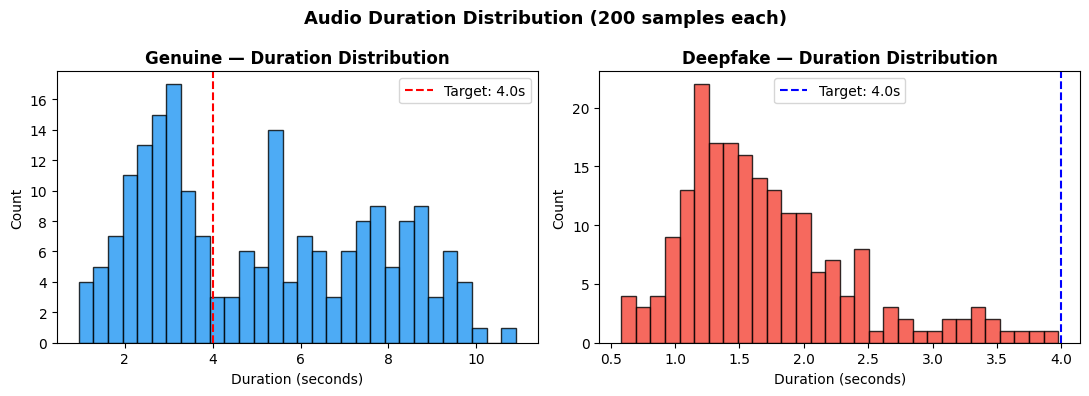

Real  — Mean: 5.07s  Std: 2.55s
Fake  — Mean: 1.71s  Std: 0.66s


In [4]:
import random
random.seed(42)

# Sample 200 files from each class to check duration
sample_real = random.sample(real_files, min(200, len(real_files)))
sample_fake = random.sample(fake_files, min(200, len(fake_files)))

real_durations, fake_durations = [], []
for fname in sample_real:
    path = os.path.join(DATA_ROOT, 'real', fname)
    dur = librosa.get_duration(filename=path)
    real_durations.append(dur)
for fname in sample_fake:
    path = os.path.join(DATA_ROOT, 'fake', fname)
    dur = librosa.get_duration(filename=path)
    fake_durations.append(dur)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(real_durations, bins=30, color='#2196F3', edgecolor='black', alpha=0.8)
axes[0].axvline(DURATION, color='red', linestyle='--', label=f'Target: {DURATION}s')
axes[0].set_title('Genuine — Duration Distribution', fontweight='bold')
axes[0].set_xlabel('Duration (seconds)'); axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].hist(fake_durations, bins=30, color='#F44336', edgecolor='black', alpha=0.8)
axes[1].axvline(DURATION, color='blue', linestyle='--', label=f'Target: {DURATION}s')
axes[1].set_title('Deepfake — Duration Distribution', fontweight='bold')
axes[1].set_xlabel('Duration (seconds)'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('Audio Duration Distribution (200 samples each)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_duration_distribution.png', dpi=150)
plt.show()
print(f'Real  — Mean: {np.mean(real_durations):.2f}s  Std: {np.std(real_durations):.2f}s')
print(f'Fake  — Mean: {np.mean(fake_durations):.2f}s  Std: {np.std(fake_durations):.2f}s')

### 2.3 Waveform Comparison


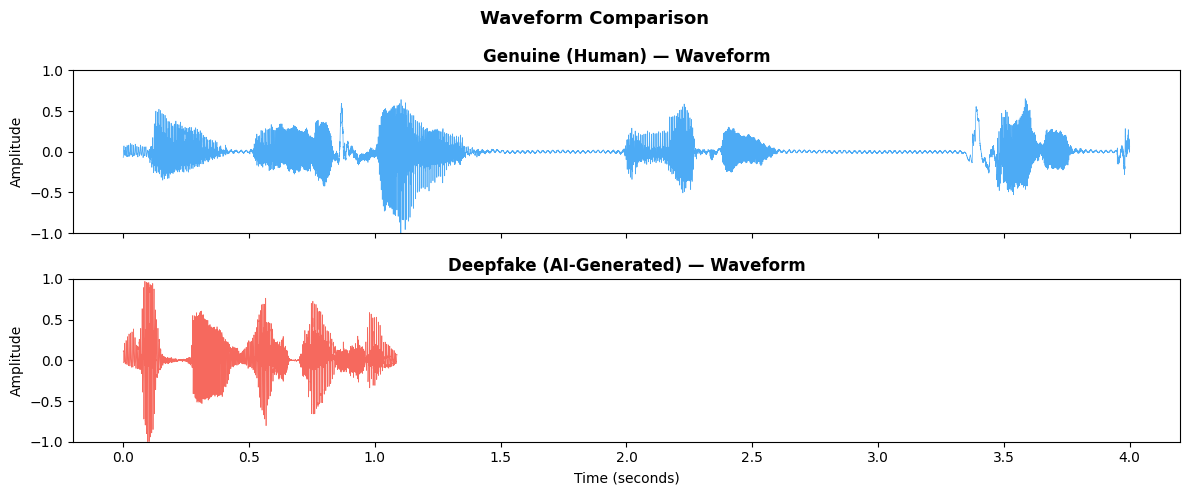

In [5]:
real_sample_path = os.path.join(DATA_ROOT, 'real', real_files[0])
fake_sample_path = os.path.join(DATA_ROOT, 'fake', fake_files[0])

y_real, _ = librosa.load(real_sample_path, sr=SR, duration=DURATION)
y_fake, _ = librosa.load(fake_sample_path, sr=SR, duration=DURATION)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t_real = np.linspace(0, len(y_real)/SR, len(y_real))
t_fake = np.linspace(0, len(y_fake)/SR, len(y_fake))

axes[0].plot(t_real, y_real, color='#2196F3', linewidth=0.5, alpha=0.8)
axes[0].set_title('Genuine (Human) — Waveform', fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1, 1)

axes[1].plot(t_fake, y_fake, color='#F44336', linewidth=0.5, alpha=0.8)
axes[1].set_title('Deepfake (AI-Generated) — Waveform', fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylim(-1, 1)

plt.suptitle('Waveform Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_waveform.png', dpi=150)
plt.show()

### 2.4 Mel Spectrogram Comparison
Frequency-time representation. Deepfake audio often shows unnaturally smooth spectral patterns — less harmonic variation.

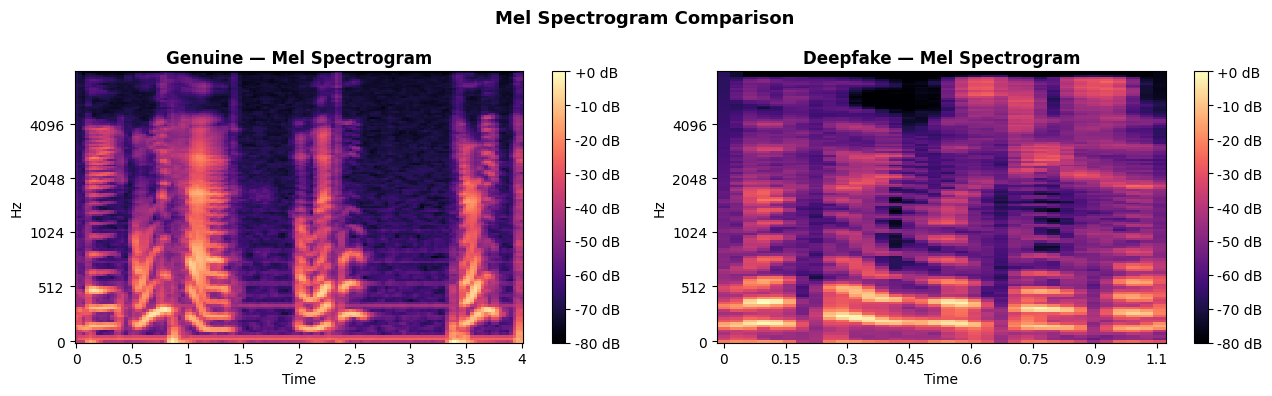

In [6]:
def plot_mel(y, sr, ax, title, color_map='magma'):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel',
                                    fmax=8000, ax=ax, cmap=color_map)
    ax.set_title(title, fontweight='bold')
    return img

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
img1 = plot_mel(y_real, SR, axes[0], 'Genuine — Mel Spectrogram')
img2 = plot_mel(y_fake, SR, axes[1], 'Deepfake — Mel Spectrogram')
plt.colorbar(img1, ax=axes[0], format='%+2.0f dB')
plt.colorbar(img2, ax=axes[1], format='%+2.0f dB')
plt.suptitle('Mel Spectrogram Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_mel_spectrogram.png', dpi=150)
plt.show()

### 2.5 MFCC Comparison
MFCCs capture the overall spectral envelope (vocal tract shape). Deepfake MFCCs tend to be smoother / less dynamic.

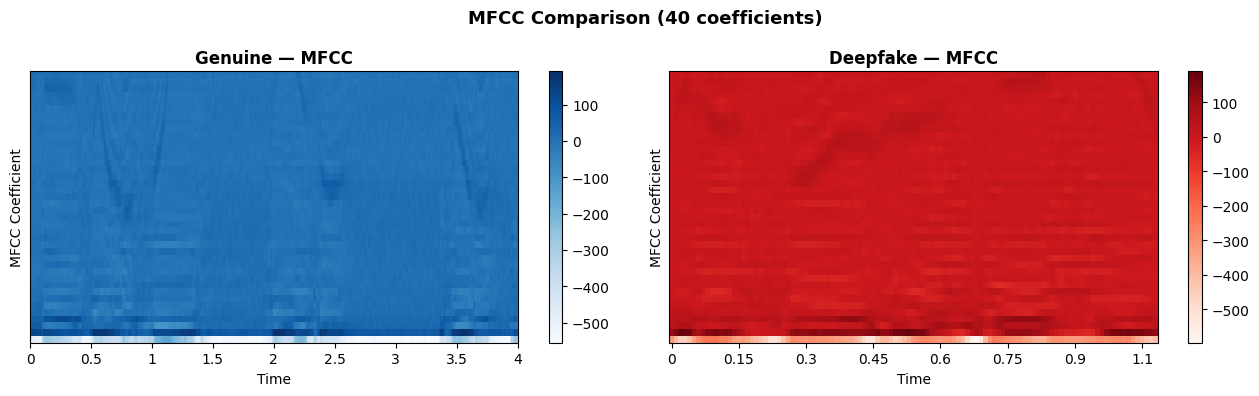

In [7]:
mfcc_real = librosa.feature.mfcc(y=y_real, sr=SR, n_mfcc=N_MFCC,
                                   hop_length=HOP_LENGTH, n_fft=N_FFT)
mfcc_fake = librosa.feature.mfcc(y=y_fake, sr=SR, n_mfcc=N_MFCC,
                                   hop_length=HOP_LENGTH, n_fft=N_FFT)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mfcc, title, cmap in zip(
    axes,
    [mfcc_real, mfcc_fake],
    ['Genuine — MFCC', 'Deepfake — MFCC'],
    ['Blues', 'Reds']
):
    img = librosa.display.specshow(mfcc, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', ax=ax, cmap=cmap)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('MFCC Coefficient')
    plt.colorbar(img, ax=ax)

plt.suptitle('MFCC Comparison (40 coefficients)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_mfcc.png', dpi=150)
plt.show()

### 2.6 MFCC Mean Distribution Across Classes
Average value of each MFCC coefficient across many samples. Significant differences indicate discriminative power.

Fake MFCC: 100%|██████████| 100/100 [00:01<00:00, 68.18it/s]


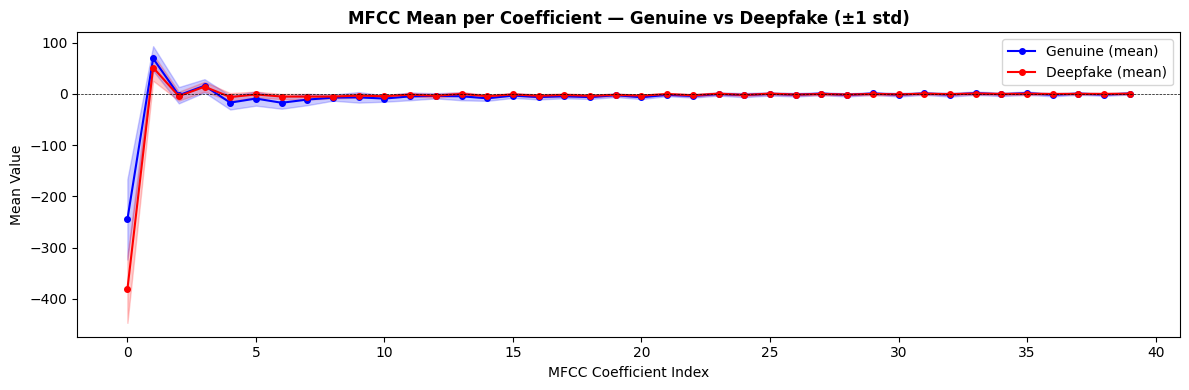

In [8]:
N_SAMPLE_EDA = 100
real_mfcc_means = []
fake_mfcc_means = []

for fname in tqdm(random.sample(real_files, N_SAMPLE_EDA), desc='Real MFCC'):
    y, _ = librosa.load(os.path.join(DATA_ROOT, 'real', fname), sr=SR, duration=DURATION)
    y = np.pad(y, (0, max(0, N_SAMPLES - len(y))))[:N_SAMPLES]
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    real_mfcc_means.append(mfcc.mean(axis=1))

for fname in tqdm(random.sample(fake_files, N_SAMPLE_EDA), desc='Fake MFCC'):
    y, _ = librosa.load(os.path.join(DATA_ROOT, 'fake', fname), sr=SR, duration=DURATION)
    y = np.pad(y, (0, max(0, N_SAMPLES - len(y))))[:N_SAMPLES]
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    fake_mfcc_means.append(mfcc.mean(axis=1))

real_mfcc_means = np.array(real_mfcc_means)
fake_mfcc_means = np.array(fake_mfcc_means)
coeff_idx = np.arange(N_MFCC)

plt.figure(figsize=(12, 4))
plt.plot(coeff_idx, real_mfcc_means.mean(axis=0), 'b-o', markersize=4, label='Genuine (mean)')
plt.fill_between(coeff_idx,
                  real_mfcc_means.mean(0) - real_mfcc_means.std(0),
                  real_mfcc_means.mean(0) + real_mfcc_means.std(0),
                  alpha=0.2, color='blue')
plt.plot(coeff_idx, fake_mfcc_means.mean(axis=0), 'r-o', markersize=4, label='Deepfake (mean)')
plt.fill_between(coeff_idx,
                  fake_mfcc_means.mean(0) - fake_mfcc_means.std(0),
                  fake_mfcc_means.mean(0) + fake_mfcc_means.std(0),
                  alpha=0.2, color='red')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.xlabel('MFCC Coefficient Index')
plt.ylabel('Mean Value')
plt.title('MFCC Mean per Coefficient — Genuine vs Deepfake (±1 std)', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('/kaggle/working/eda_mfcc_means.png', dpi=150)
plt.show()


## 3. Feature Extraction

- **MFCC** uses a *Mel (log-spaced)* filterbank — captures perceptual speech features, good for speaker ID
- **LFCC** uses a *linear-spaced* filterbank — deepfake artifacts from vocoders (Griffin-Lim, WaveNet) appear in high-frequency linear bands that Mel filterbanks compress/hide


In [9]:
def load_audio(path):
    """Load, resample, pad/trim to fixed N_SAMPLES."""
    y, _ = librosa.load(path, sr=SR, mono=True)
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))   # zero-pad at end
    else:
        y = y[:N_SAMPLES]                          # trim
    return y


def extract_lfcc(y):
    """
    LFCC: Linear Frequency Cepstral Coefficients.
    Unlike librosa.filters.mel (log-spaced), we create a linearly-spaced
    filterbank by setting htk=False and norm=None, then apply DCT (via mfcc).
    """
    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)) ** 2
    lin_filters = librosa.filters.mel(
        sr=SR, n_fft=N_FFT, n_mels=N_LFCC,
        fmin=0, fmax=SR // 2, norm=None, htk=False
    )
    lin_spec = np.dot(lin_filters, S)
    lin_spec = np.where(lin_spec == 0, np.finfo(float).eps, lin_spec)
    lfcc = librosa.feature.mfcc(S=librosa.power_to_db(lin_spec), n_mfcc=N_LFCC)
    return lfcc   # shape: (40, T)


def extract_features(path):
    """
    Final feature tensor for one audio file.
    Output shape: (80, T) — 40 LFCC rows + 40 MFCC rows stacked vertically.
    Per-feature normalised (zero mean, unit variance along time axis).
    """
    y    = load_audio(path)
    lfcc = extract_lfcc(y)                              # (40, T)
    mfcc = librosa.feature.mfcc(y=y, sr=SR,
                                 n_mfcc=N_MFCC,
                                 hop_length=HOP_LENGTH,
                                 n_fft=N_FFT)           # (40, T)
    feat = np.vstack([lfcc, mfcc])                      # (80, T)
    # Normalise each row independently
    feat = (feat - feat.mean(axis=1, keepdims=True)) / \
           (feat.std(axis=1, keepdims=True) + 1e-8)
    return feat.astype(np.float32)


print('Feature functions defined.')


Feature functions defined.


### 3.1 Visualise Final Feature Map

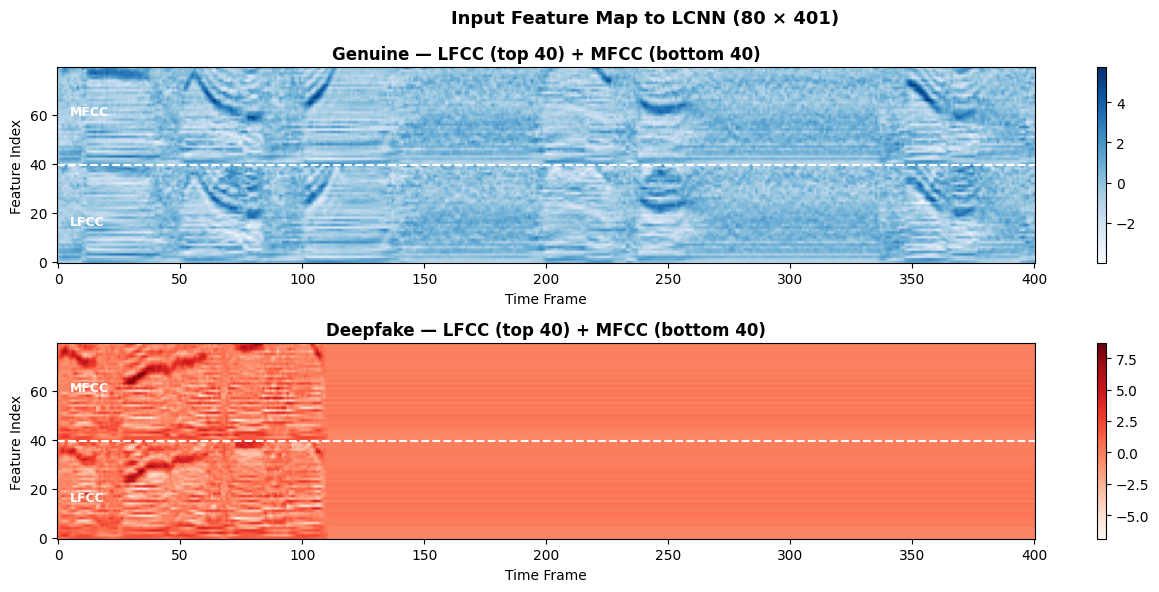

In [10]:
feat_real = extract_features(real_sample_path)
feat_fake = extract_features(fake_sample_path)

fig, axes = plt.subplots(2, 1, figsize=(13, 6))
for ax, feat, title, cmap in zip(
    axes,
    [feat_real, feat_fake],
    ['Genuine — LFCC (top 40) + MFCC (bottom 40)', 'Deepfake — LFCC (top 40) + MFCC (bottom 40)'],
    ['Blues', 'Reds']
):
    im = ax.imshow(feat, aspect='auto', origin='lower', cmap=cmap)
    ax.axhline(39.5, color='white', linewidth=1.5, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('Feature Index')
    ax.text(5, 60, 'MFCC', color='white', fontsize=9, fontweight='bold')
    ax.text(5, 15, 'LFCC', color='white', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.suptitle('Input Feature Map to LCNN (80 × 401)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_feature_map.png', dpi=150)
plt.show()

### 3.2 Batch Feature Extraction & Caching
Extract features for all 53,868 clips once and cache to disk as `.npy` files. Subsequent runs load from cache instantly.

In [11]:
os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_X = os.path.join(CACHE_DIR, 'X.npy')
CACHE_Y = os.path.join(CACHE_DIR, 'y.npy')

if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y):
    print('Loading cached features...')
    X = np.load(CACHE_X)
    y = np.load(CACHE_Y)
else:
    print('Extracting features (first run ~20 min)...')
    X_list, y_list = [], []
    for label, folder in [(0, 'real'), (1, 'fake')]:
        folder_path = os.path.join(DATA_ROOT, folder)
        files = [f for f in os.listdir(folder_path)
                 if f.endswith('.wav') or f.endswith('.flac')]
        for fname in tqdm(files, desc=folder):
            try:
                feat = extract_features(os.path.join(folder_path, fname))
                X_list.append(feat)
                y_list.append(label)
            except Exception as e:
                print(f'  Skip {fname}: {e}')

    T_MAX  = max(x.shape[1] for x in X_list)
    X_list = [np.pad(x, ((0,0),(0, T_MAX - x.shape[1]))) if x.shape[1] < T_MAX
               else x[:, :T_MAX] for x in X_list]
    X = np.stack(X_list)[:, np.newaxis, :, :]   # (N, 1, 80, T)
    y = np.array(y_list)
    np.save(CACHE_X, X)
    np.save(CACHE_Y, y)
    print(f'Saved. X shape: {X.shape}')

print(f'X: {X.shape}  |  y: {y.shape}')
print(f'Genuine: {(y==0).sum():,}  |  Deepfake: {(y==1).sum():,}')

Extracting features (first run ~20 min)...


fake: 100%|██████████| 26927/26927 [09:50<00:00, 45.59it/s]


Saved. X shape: (53868, 1, 80, 401)
X: (53868, 1, 80, 401)  |  y: (53868,)
Genuine: 26,941  |  Deepfake: 26,927


## 4. Dataset & DataLoaders




In [12]:
class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


idx = np.arange(len(y))
idx_train, idx_temp = train_test_split(idx, test_size=VAL_SPLIT + TEST_SPLIT,
                                        stratify=y, random_state=SEED)
idx_val, idx_test   = train_test_split(idx_temp,
                                        test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
                                        stratify=y[idx_temp], random_state=SEED)

train_loader = DataLoader(AudioDataset(X[idx_train], y[idx_train]),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(AudioDataset(X[idx_val],   y[idx_val]),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(AudioDataset(X[idx_test],  y[idx_test]),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(idx_train):,} clips')
print(f'Val   : {len(idx_val):,} clips')
print(f'Test  : {len(idx_test):,} clips')
print(f'Input tensor shape: {X[0].shape}  (channels=1, freq=80, time=401)')

Train : 40,401 clips
Val   : 8,080 clips
Test  : 5,387 clips
Input tensor shape: (1, 80, 401)  (channels=1, freq=80, time=401)


## 5. Model Architecture - LCNN




In [13]:
class MFM(nn.Module):
    """Max-Feature-Map: splits channels in half, returns element-wise max."""
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)   # split along channel dim
        return torch.max(x1, x2)      # (B, C/2, H, W)


class ConvBlock(nn.Module):
    """Conv2d → BN → MFM. Outputs out_ch channels (not out_ch*2)."""
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch * 2, k, s, p, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch * 2)
        self.mfm  = MFM()
    def forward(self, x):
        return self.mfm(self.bn(self.conv(x)))


class LCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 32),   
            nn.MaxPool2d(2, 2),
            ConvBlock(32, 64),           
            nn.MaxPool2d(2, 2),
            ConvBlock(64, 96),            
            ConvBlock(96, 96),            
            nn.MaxPool2d(2, 2),
            ConvBlock(96, 128),           
            ConvBlock(128, 128),         
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),  # fixed spatial size regardless of input
            nn.Flatten(),
            nn.Linear(128 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),              # regularisation
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = LCNN(in_channels=1).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
print(model)

Trainable parameters: 1,357,250
LCNN(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (mfm): MFM()
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (conv): Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (mfm): MFM()
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ConvBlock(
      (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (mfm): MFM()
    )
    (5): ConvBlock(
      (conv): Conv2d(96, 192, kernel_size=(3, 3), stride=(

## 6. Training


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, labels = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.cpu().numpy())
    return total_loss / len(labels), accuracy_score(labels, preds)


history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    saved = vl_acc > best_val_acc
    if saved:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), MODEL_PATH)

    print(f'Epoch {epoch:03d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}'
          + (' ← saved' if saved else ''))

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 001/20 | Train Loss: 0.1156 Acc: 0.9587 | Val Loss: 0.1731 Acc: 0.9506 ← saved
Epoch 002/20 | Train Loss: 0.0453 Acc: 0.9854 | Val Loss: 0.4198 Acc: 0.8722
Epoch 003/20 | Train Loss: 0.0302 Acc: 0.9899 | Val Loss: 0.0225 Acc: 0.9918 ← saved
Epoch 004/20 | Train Loss: 0.0245 Acc: 0.9924 | Val Loss: 1.5284 Acc: 0.6671
Epoch 005/20 | Train Loss: 0.0198 Acc: 0.9933 | Val Loss: 0.0112 Acc: 0.9957 ← saved
Epoch 006/20 | Train Loss: 0.0169 Acc: 0.9946 | Val Loss: 0.0616 Acc: 0.9833
Epoch 007/20 | Train Loss: 0.0142 Acc: 0.9952 | Val Loss: 0.3953 Acc: 0.8790
Epoch 008/20 | Train Loss: 0.0148 Acc: 0.9955 | Val Loss: 0.0237 Acc: 0.9918
Epoch 009/20 | Train Loss: 0.0115 Acc: 0.9963 | Val Loss: 0.0187 Acc: 0.9942
Epoch 010/20 | Train Loss: 0.0075 Acc: 0.9977 | Val Loss: 0.0108 Acc: 0.9959 ← saved
Epoch 011/20 | Train Loss: 0.0067 Acc: 0.9978 | Val Loss: 0.0199 Acc: 0.9934
Epoch 012/20 | Train Loss: 0.0059 Acc: 0.9980 | Val Loss: 0.0142 Acc: 0.9957
Epoch 013/20 | Train Loss: 0.0047 Acc: 0.998

### 6.1 Training Curves

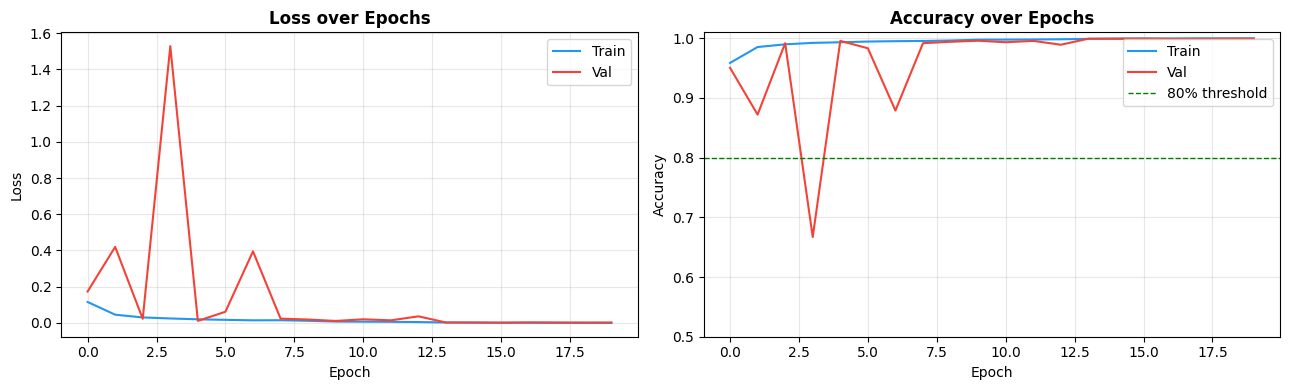

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['train_loss'], label='Train', color='#2196F3')
ax1.plot(history['val_loss'],   label='Val',   color='#F44336')
ax1.set_title('Loss over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train', color='#2196F3')
ax2.plot(history['val_acc'],   label='Val',   color='#F44336')
ax2.set_title('Accuracy over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.5, 1.01)
ax2.axhline(0.80, color='green', linestyle='--', linewidth=1, label='80% threshold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## 7. Evaluation on Test Set


In [16]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_scores = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb    = xb.to(DEVICE)
        probs = F.softmax(model(xb), dim=1).cpu().numpy()
        all_preds.extend(np.argmax(probs, axis=1))
        all_labels.extend(yb.numpy())
        all_scores.extend(probs[:, 1])  # P(deepfake)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_scores = np.array(all_scores)
print('Inference complete.')

Inference complete.


### 7.1 Performance Report

In [17]:
accuracy      = accuracy_score(all_labels, all_preds)
f1            = f1_score(all_labels, all_preds, average='macro')
cm            = confusion_matrix(all_labels, all_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
auc           = roc_auc_score(all_labels, all_scores)

fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
fnr     = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer     = fpr[eer_idx]

print('╔══════════════════════════════════════════════╗')
print('║          PERFORMANCE REPORT                  ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Overall Accuracy : {accuracy*100:.2f}%  (req ≥80%)  {"yes" if accuracy>=0.80 else "no"}         ║')
print(f'║  F1 Score (macro) : {f1*100:.2f}%  (req ≥80%)  {"yes" if f1>=0.80 else "no"}         ║')
print(f'║  EER              : {eer*100:.2f}%   (req ≤12%)  {"yes" if eer<=0.12 else "no"}        ║')
print(f'║  AUC-ROC          : {auc:.4f}                         ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Genuine  Accuracy: {per_class_acc[0]*100:.2f}%  (req ≥75%)  {"yes" if per_class_acc[0]>=0.75 else "no"}         ║')
print(f'║  Deepfake Accuracy: {per_class_acc[1]*100:.2f}%  (req ≥75%)  {"yes" if per_class_acc[1]>=0.75 else "no"}         ║')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║          PERFORMANCE REPORT                  ║
╠══════════════════════════════════════════════╣
║  Overall Accuracy : 99.89%  (req ≥80%)  yes         ║
║  F1 Score (macro) : 99.89%  (req ≥80%)  yes         ║
║  EER              : 0.15%   (req ≤12%)  yes        ║
║  AUC-ROC          : 1.0000                         ║
╠══════════════════════════════════════════════╣
║  Genuine  Accuracy: 99.85%  (req ≥75%)  yes         ║
║  Deepfake Accuracy: 99.93%  (req ≥75%)  yes         ║
╚══════════════════════════════════════════════╝


### 7.2 Confusion Matrix

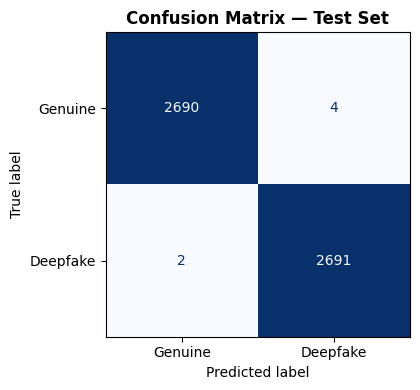

Correct: 5,381  |  Errors: 6  |  Total: 5,387


In [18]:
plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['Genuine', 'Deepfake'])
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()
print(f'Correct: {cm[0,0]+cm[1,1]:,}  |  Errors: {cm[0,1]+cm[1,0]}  |  Total: {cm.sum():,}')

### 7.3 ROC Curve

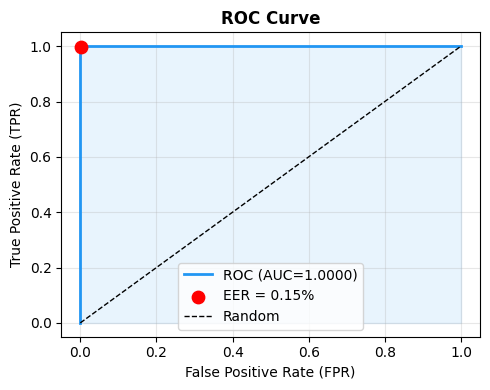

In [19]:
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2, label=f'ROC (AUC={auc:.4f})')
plt.scatter(fpr[eer_idx], tpr[eer_idx], color='red', zorder=5, s=80,
            label=f'EER = {eer*100:.2f}%')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()

### 7.4 Confidence Score Distribution


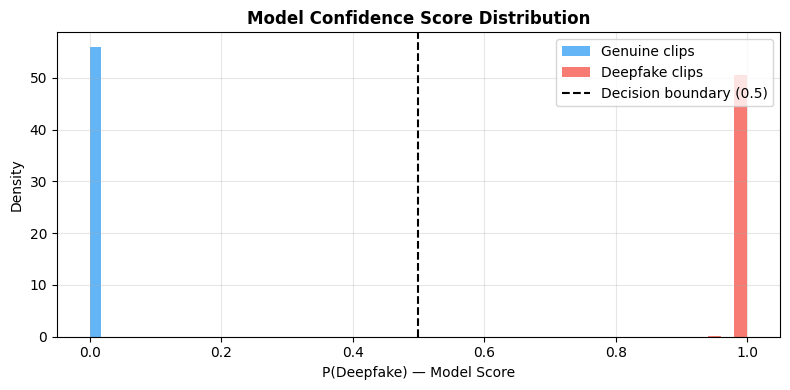

→ Bimodal distribution (peaks near 0 and 1) = model is highly confident.


In [20]:
genuine_scores  = all_scores[all_labels == 0]   # P(deepfake) for real clips — should be LOW
deepfake_scores = all_scores[all_labels == 1]   # P(deepfake) for fake clips — should be HIGH

plt.figure(figsize=(8, 4))
plt.hist(genuine_scores,  bins=50, alpha=0.7, color='#2196F3', label='Genuine clips',  density=True)
plt.hist(deepfake_scores, bins=50, alpha=0.7, color='#F44336', label='Deepfake clips', density=True)
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
plt.xlabel('P(Deepfake) — Model Score')
plt.ylabel('Density')
plt.title('Model Confidence Score Distribution', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/score_distribution.png', dpi=150)
plt.show()
print('→ Bimodal distribution (peaks near 0 and 1) = model is highly confident.')

## 8. Inference - Single File Prediction

In [21]:
def predict_single(audio_path, model, t_expected=401, device=DEVICE):
    """
    Predict whether an audio file is Genuine or Deepfake.
    Returns: (label_string, confidence_%, [P_genuine, P_deepfake])
    """
    feat = extract_features(audio_path)            # (80, T)
    if feat.shape[1] < t_expected:
        feat = np.pad(feat, ((0,0),(0, t_expected - feat.shape[1])))
    else:
        feat = feat[:, :t_expected]
    tensor = torch.tensor(feat[np.newaxis, np.newaxis],
                           dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1).cpu().numpy()[0]
    pred  = int(np.argmax(probs))
    label = 'Deepfake (AI-Generated)' if pred == 1 else 'Genuine (Human)'
    return label, probs[pred] * 100, probs


# ── Demo on one real and one fake file 
T_EXPECTED = X.shape[-1]  # 401

for test_path, true_label in [
    (os.path.join(DATA_ROOT, 'real', real_files[10]), 'Genuine'),
    (os.path.join(DATA_ROOT, 'fake', fake_files[10]), 'Deepfake')
]:
    label, conf, probs = predict_single(test_path, model, T_EXPECTED)
    correct = 'YES' if true_label.lower() in label.lower() else 'NO'
    print(f'{correct}  True: {true_label:8s}  |  Predicted: {label:25s}  |  Confidence: {conf:.1f}%')

YES  True: Genuine   |  Predicted: Genuine (Human)            |  Confidence: 100.0%
YES  True: Deepfake  |  Predicted: Deepfake (AI-Generated)    |  Confidence: 100.0%
